# Diabetes Risk Prediction using Machine Learning


Machine learning classification project focused on predicting diabetes risk using demographic and clinical patient data.

Features:

Age
Gender
BMI
Hypertension
Heart disease
Smoking history
HbA1c level
Blood glucose level

Tools: Python, Pandas, Scikit-learn, Matplotlib, Seaborn

Author: Aida Badenova | nFactorial School

Описание задания

Вам необходимо построить модель-классификатор по определению диабета. У вас нет никаких ограничений по инструментам, новым полям и способу энкодинга данных.

# О данных

Датасет представляет собой набор медицинских и демографических данных пациентов, а также их диагноз по диабету (положительный или отрицательный). 

Данные включают такие характеристики, как возраст, пол, индекс массы тела (BMI), гипертония, болезни сердца, история курения, уровень HbA1c и уровень глюкозы в крови. Этот набор данных можно использовать для создания моделей машинного обучения для прогнозирования диабета у пациентов на основе их истории болезни и демографической информации.

# Submission задания

Вам будет предоставлен второй датасет, без целевой переменной (таргет - diabetes)
Этот датасет необходимо будет проскорить и сабмитнуть в Google Classroom в формате .csv, с 2 столбцами: `ID` и `prediction`

Поле `prediction` должно быть предсказанием **<span style = 'color : green'> класса </span>** (`predict`), т.е. 1 или 0 а **<span style = 'color : red'>не вероятности </span>** (`predict_proba`)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay)

import warnings
warnings.filterwarnings ('ignore')
sns.set_theme()
print('Готово!')

Готово!


In [2]:
df = pd.read_csv('training_data - training_data.csv') 
print(df.shape)
df.head()

(73718, 11)


,Unnamed: 0,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,78830894-cdd8-43d1-9655-03db74141b7a,Female,80.0,0,1,never,25.19,6.6,140,0
1,1,32262c0e-903a-46b8-9061-b1a2f5a3e9b2,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,2,c4868b73-ca90-48ed-af14-3d1f78a5f030,Male,28.0,0,0,never,27.32,5.7,158,0
3,3,bec2ef91-5aff-48df-ac16-cb210b5f29fa,Female,36.0,0,0,current,23.45,5.0,155,0
4,4,1a6852a8-ee80-4d93-bea0-f0cdd941dc3d,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
print(df.dtypes)
print()
print(df.isna().sum())

Unnamed: 0               int64
ID                         str
gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level      int64
diabetes                 int64
dtype: object

Unnamed: 0             0
ID                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64


In [4]:
print('Распределение диабета:')
print(df['diabetes'].value_counts())
print ()
print ('В процентах:')
print(df['diabetes'].value_counts(normalize=True).round(2))


Распределение диабета:
diabetes
0    67168
1     6550
Name: count, dtype: int64

В процентах:
diabetes
0    0.91
1    0.09
Name: proportion, dtype: float64


In [5]:
df.describe() 

,Unnamed: 0,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,73718.000000,73718.000000,73718.000000,73718.000000,73718.000000,73718.000000,73718.000000,73718.000000
mean,36858.500000,41.852959,0.078963,0.040858,27.348037,5.534038,138.197835,0.088852
std,21280.697909,22.488153,0.269683,0.197963,6.776093,1.070917,40.892972,0.284532
min,0.000000,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,18429.250000,24.000000,0.000000,0.000000,23.430000,4.800000,100.000000,0.000000
50%,36858.500000,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,55287.750000,59.000000,0.000000,0.000000,29.900000,6.200000,159.000000,0.000000
max,73717.000000,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


In [6]:
print('Gender:')
print(df['gender'].value_counts())
print()
print('Smoking history:')
print(df['smoking_history'].value_counts())

Gender:
gender
Female    43097
Male      30609
Other        12
Name: count, dtype: int64

Smoking history:
smoking_history
never          26296
No Info        25236
former          7150
current         7035
not current     4958
ever            3043
Name: count, dtype: int64


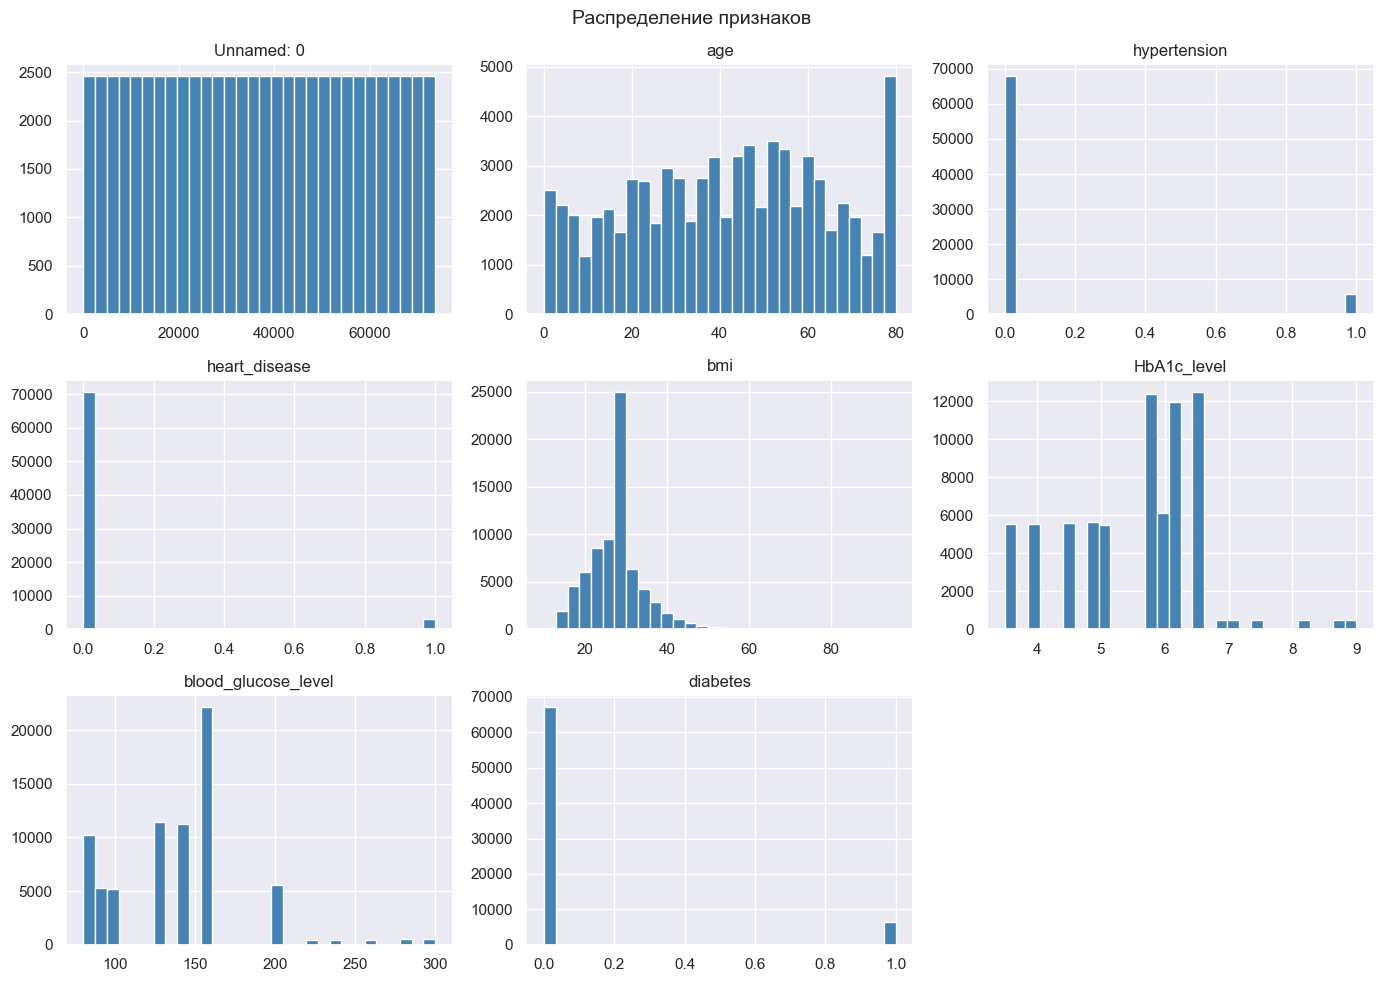

In [7]:
df.hist(figsize=(14, 10), bins=30, color='steelblue', edgecolor= 'white')
plt.suptitle('Распределение признаков', fontsize = 14)
plt.tight_layout()
plt.show()

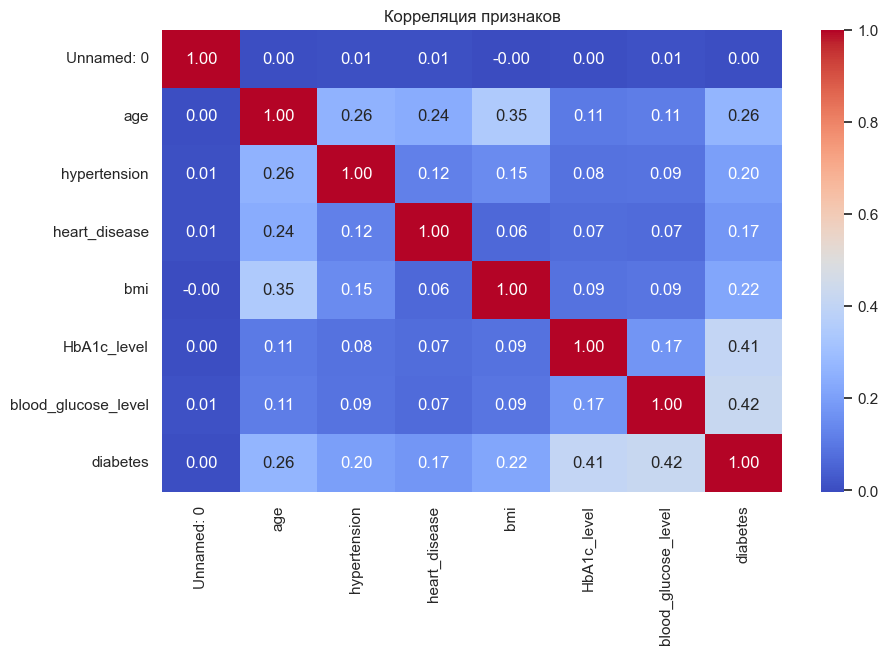

In [8]:
df_numeric = df.select_dtypes(include = ['int64', 'float64'])
plt.figure(figsize=(10, 6))
sns.heatmap (df_numeric.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Корреляция признаков')
plt.show()           

In [9]:
df = df.drop(columns=['Unnamed: 0', 'ID'], errors = 'ignore')

print('Оставшиеся столбцы:', df.columns.tolist())

Оставшиеся столбцы: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']


In [10]:
x = df.drop(columns = ['diabetes'])

y = df['diabetes']

print('Фичи:', x.columns.tolist())
print('Размер x:', x.shape)

Фичи: ['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Размер x: (73718, 8)


In [11]:

x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

print('Train:', len(x_train))
print ('Validation:', len(x_val))
print()
print ('Дисбаланс в train:')
print(y_train.value_counts(normalize=True).round(2))

Train: 58974
Validation: 14744

Дисбаланс в train:
diabetes
0    0.91
1    0.09
Name: proportion, dtype: float64


In [12]:
numeric_features = x_train.select_dtypes(include=['int64', 'float64']).columns
categorial_features = x_train.select_dtypes(include=['object']).columns

print('Числовые:', numeric_features.tolist())
print('Категориальные:', categorial_features.tolist())

Числовые: ['age', 'hypertension', 'heart_disease', 'bmi', 'HbA1c_level', 'blood_glucose_level']
Категориальные: ['gender', 'smoking_history']


In [13]:
numeric_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorial_transformer = Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')), ('encoder', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer (transformers=[('num', numeric_transformer, numeric_features), ('cat', categorial_transformer, categorial_features)])

print('Preprocessor готов!')

Preprocessor готов!


In [14]:
model = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_leaf=4, class_weight='balanced', random_state=42, n_jobs=-1))])

print('Pipeline создан!')

Pipeline создан!


In [15]:
model.fit(x_train, y_train)
print('Модель обучена!')

Модель обучена!


In [16]:
y_pred = model.predict(x_val)
y_proba = model.predict_proba(x_val)[:, 1]

print('Предсказания готовы!')

Предсказания готовы!


In [17]:
print('=== Порог 0.5 ===')

print ('Accuracy:', round (accuracy_score(y_val, y_pred), 4))
print ('Precision:', round (precision_score(y_val, y_pred), 4))
print('Recall:', round(recall_score(y_val, y_pred), 4))
print('F1-score:', round(f1_score(y_val, y_pred), 4))
print('ROC-AUC:', round(roc_auc_score(y_val, y_proba), 4))
print()
print(classification_report(y_val, y_pred, target_names=['Нет диабета', 'Есть диабет']))

=== Порог 0.5 ===
Accuracy: 0.9092
Precision: 0.494
Recall: 0.9122
F1-score: 0.6409
ROC-AUC: 0.9775

              precision    recall  f1-score   support

 Нет диабета       0.99      0.91      0.95     13434
 Есть диабет       0.49      0.91      0.64      1310

    accuracy                           0.91     14744
   macro avg       0.74      0.91      0.79     14744
weighted avg       0.95      0.91      0.92     14744



In [18]:
y_pred_adjusted = (y_proba >= 0.3).astype(int)

print('=== Порог 0.3 ===')

print('ROC-AUC:', round(roc_auc_score(y_val, y_proba), 4))
print()
print(classification_report(y_val, y_pred_adjusted, target_names= ['Нет диабета', 'Есть диабет']))

=== Порог 0.3 ===
ROC-AUC: 0.9775

              precision    recall  f1-score   support

 Нет диабета       1.00      0.82      0.90     13434
 Есть диабет       0.34      0.98      0.51      1310

    accuracy                           0.83     14744
   macro avg       0.67      0.90      0.70     14744
weighted avg       0.94      0.83      0.86     14744



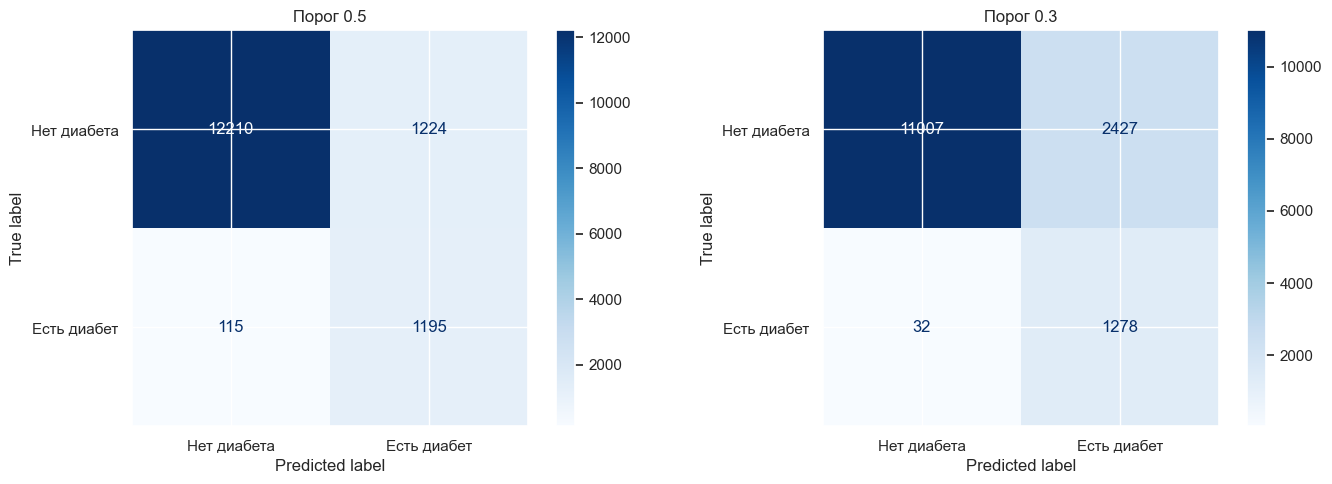

In [19]:
fig, axes = plt.subplots(1, 2, figsize = (14, 5))

ConfusionMatrixDisplay(confusion_matrix(y_val, y_pred), display_labels=['Нет диабета', 'Есть диабет']). plot(ax=axes[0], cmap='Blues')
axes[0].set_title('Порог 0.5')

ConfusionMatrixDisplay (confusion_matrix(y_val, y_pred_adjusted), display_labels=['Нет диабета', 'Есть диабет']).plot(ax=axes[1], cmap='Blues')
axes[1].set_title ('Порог 0.3')

plt.tight_layout()
plt.show()

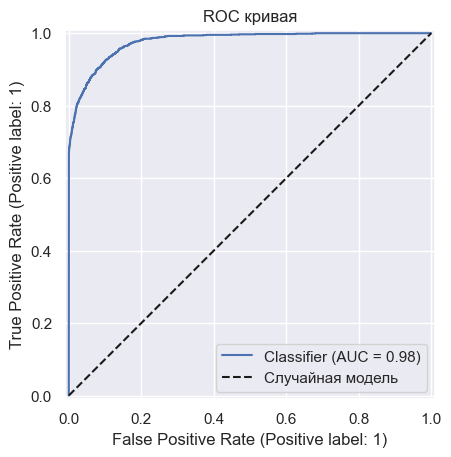

In [20]:
RocCurveDisplay.from_predictions(y_val, y_proba)
plt.title('ROC кривая')
plt.plot([0,1], [0,1], 'k--', label='Случайная модель')
plt.legend()
plt.show()

                    feature  importance
4               HbA1c_level    0.410412
5       blood_glucose_level    0.276802
0                       age    0.152212
3                       bmi    0.078240
1              hypertension    0.036459
2             heart_disease    0.019002
9   smoking_history_No Info    0.014331
12   smoking_history_former    0.006123
7               gender_Male    0.001894
6             gender_Female    0.001658


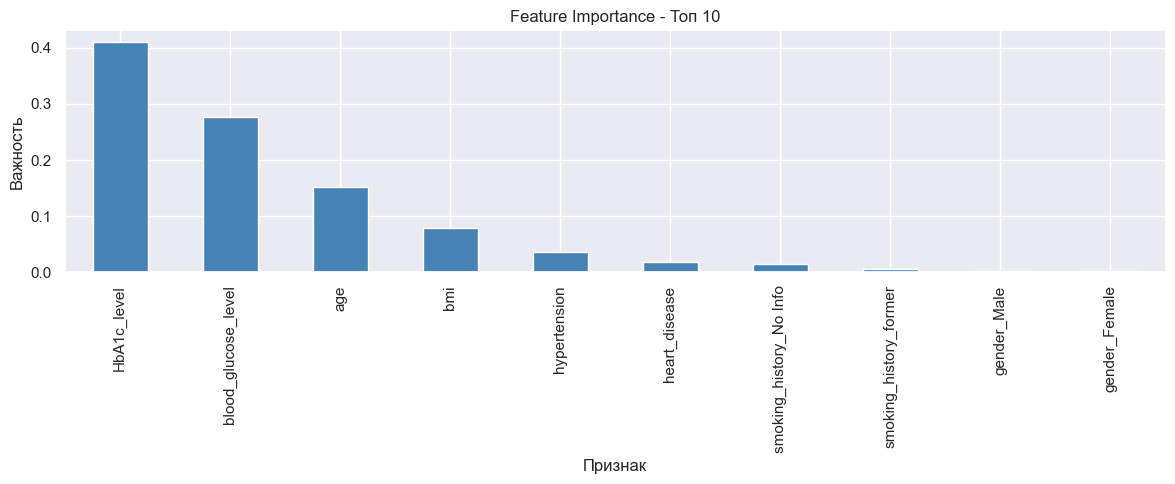

In [21]:
rf_model = model.named_steps['classifier']

ohe_features = (model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorial_features))

all_features = list(numeric_features) + list (ohe_features)

fi = pd.DataFrame({'feature': all_features, 'importance': rf_model.feature_importances_}).sort_values('importance', ascending=False).head(10)

print(fi)

fi.plot(kind= 'bar', x='feature', y='importance', figsize= (12, 5), color='steelblue', legend=False)
plt.title('Feature Importance - Топ 10')
plt.xlabel('Признак')
plt.ylabel('Важность')
plt.tight_layout()
plt.show()

In [22]:
df_test = pd.read_csv('test_data - test_data.csv')
print(df_test.shape)
df_test.head()

(26146, 10)


,Unnamed: 0,ID,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0,ba0d6256-ca6e-46a7-a2fb-2518a8937fd7,Female,60.0,1,0,former,23.77,4.8,130
1,1,7102b1ab-c7a4-4a43-b1fc-cb588d0553b8,Male,2.0,0,0,No Info,15.19,5.0,159
2,2,51ba207e-4934-41b4-a31c-cd275c5ca555,Female,74.0,0,0,not current,39.59,6.5,160
3,3,7e17faaa-0402-4728-9719-83982eba3afd,Female,51.0,0,0,never,26.67,6.6,80
4,4,08b4e515-286e-4393-9a55-138962f9546e,Male,35.0,0,0,never,26.09,3.5,159


In [23]:

test_ids = df_test['ID']

df_test = df_test.drop(columns=['Unnamed: 0', 'ID'], errors='ignore')

print('Тест готов!')
print(df_test.shape)


Тест готов!
(26146, 8)


In [24]:
test_proba = model.predict_proba(df_test)[:, 1]

test_pred = (test_proba >= 0.3).astype(int)

print('Предсказания готовы!')
print('Распределение:')
print(pd.Series(test_pred).value_counts())

Предсказания готовы!
Распределение:
0    19688
1     6458
Name: count, dtype: int64


In [25]:
submission = pd.DataFrame ({'ID': test_ids.values, 'prediction': test_pred})

submission.to_csv('submission.csv', index=False)

print('Submission сохранен!')
print(submission.head(10))
print()
print('Итого предсказаний:', len(submission))

Submission сохранен!
                                     ID  prediction
0  ba0d6256-ca6e-46a7-a2fb-2518a8937fd7           0
1  7102b1ab-c7a4-4a43-b1fc-cb588d0553b8           0
2  51ba207e-4934-41b4-a31c-cd275c5ca555           1
3  7e17faaa-0402-4728-9719-83982eba3afd           0
4  08b4e515-286e-4393-9a55-138962f9546e           0
5  ae8c742d-47f9-4aa8-b246-8309430bcf8d           0
6  6a840d8c-d7d8-49c6-8412-4a6dd8f2cbd0           0
7  1e51ca84-e391-4f90-b225-cb0cdc3508a5           1
8  ba9513a6-6f18-44de-a46e-f308b13d6905           0
9  b7843957-4835-4612-a922-6e964a7c0dd3           0

Итого предсказаний: 26146


###Выводы:
датасет: 73718 пациентов, 8 признаков
дисбаланс классов: 91% нет диабета/9% есть диабет
решение дисбаланса: sample_weights='balanced'внутри модели
Архитектура — Pipeline
- Pipeline (preprocessor + RandomForestClassifier)
- Нет data leakage: encoding и scaling обучались только на X_train
- StandardScaler для числовых признаков
- OneHotEncoder для категориальных признаков (gender, smoking_history)
- SimpleImputer для пропущенных значений 

###Метрики 
Порог 0.5:
- Accuracy:  0.91
- Precision: 0.49
- Recall:    0.91
- F1-score:  0.64
- ROC-AUC:   0.98

Порог 0.3:
- Recall:    0.98 (находим 98% всех больных!)
- ROC-AUC:   0.98 (не меняется — не зависит от порога!)

###Выбор порога для Submission:
Выбран порог 0.3 потому что:
- Recall растёт с 0.91 до 0.98
- Находим 98% всех больных диабетом
- Пропускаем только 2% больных вместо 9%
- Для медицины важнее не пропустить больного
  чем избежать ложных тревог!
- ROC-AUC = 0.98! не зависит от порога

###Важнейшие признаки:
1. HbA1c_level    0.329043 - главный маркер
2. blood_glucose_level    0.272676
3. age    0.192386
4. bmi    0.127240

###Медицинский вывод: результаты фичи полностью совпадают с медицинской наукой - HbA1c_level(гликированный гемоглобин) и глюкоза являются ключевыми клиническими показателями, связанными с диагностикой диабета. Feature importance показывает, что модель в первую очередь опирается на клинически логичные признаки: HbA1c, glucose, age и BMI.

Submission: 26146 предсказаний сохранены в submission.csv 
            Формат: ID + prediction (0 или 1)
            Использован порог 0.3 для максимального Recall